# Explore the idea behind ORF finder
We will first use a simulation to understand the main intuition behind the ORF finder algorithm, i.e., how it attempts to identify an Open Reading Frame on a piece of DNA sequence. Then, we will test this naive idea on a read protein coding DNA and a shuffled version of it, to see the idea in action

## Simulation
We will simulate 500 random DNA sequences, each 300 bp long.

In [6]:
import random

def generate_random_dna_strings(num_strings, string_length):
    nucleotides = ['A', 'T', 'C', 'G']
    random_strings = []

    # _ is a convention to indicate the we won't be using the index in the loop
    for _ in range(num_strings):
        random_string = ''.join(random.choice(nucleotides) for _ in range(string_length))
        random_strings.append(random_string)
    return random_strings

# Generate 500 random strings, each 300 characters long
num_strings = 500
string_length = 300
dna_strings = generate_random_dna_strings(num_strings, string_length)

# Print the first few strings to verify
for i, s in enumerate(dna_strings[:5]):
    print(f"String {i+1}: {s[:60]} ...")
print(f"\nTotal generated strings: {len(dna_strings)}")

String 1: ATGAAGTGGATTAAGCTGGTACCTCTTTCTATCGTTATGTGACGGGTCGCTGGATTAAGC ...
String 2: TCAGGGCCCCGCTATTGCAACTCGACAGTGAGCACGCGACGCATAGCAATCAACATGAAA ...
String 3: TTGCATGGACAAGACAGGGTGGCCAGTCTCGTTTGCGTTGCTAAGTTGGTCTCTCCTCCT ...
String 4: CAGCTGTAACCCAGCCTCAACTATAAAGTCGTGATATCTTGGTGCCTTCCTTAGTCTCAG ...
String 5: TCACGCTAAGTGAGAGGCTAAAACTCCCCTTACGGCTATTAGTAGAATTGTACGAACGGA ...

Total generated strings: 500


In [8]:
genetic_code = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',

    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',

    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',

    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

def translate_dna(dna_sequence, frame):
    amino_acids = []
    # Iterate through the sequence starting from the given frame, in steps of 3
    for i in range(frame, len(dna_sequence) - 2, 3):
        codon = dna_sequence[i:i+3]
        if codon in genetic_code:
            amino_acid = genetic_code[codon]
            if amino_acid == '*': # Stop translation at a stop codon
                break
            amino_acids.append(amino_acid)
        # If a codon is not in the genetic code (e.g., Ns or unexpected characters),
        # it's skipped. Given the generation method, this shouldn't happen with A,T,C,G.
    return ''.join(amino_acids)

# List to store translated sequences for each DNA string (only frame 0)
translated_sequences = []

for dna_string in dna_strings:
    # Only translate for frame 0
    aa_sequence = translate_dna(dna_string, frame=0)
    translated_sequences.append(aa_sequence)

# Print the first few translated sequences to verify
print("Translations for the first 5 DNA strings (frame 0 only):")
for i, aa_sequence in enumerate(translated_sequences[:5]):
    print(f"String {i+1}: {dna_strings[i][:60]} ...")
    print(f"  Frame 0: {aa_sequence}")
    print()

print(f"\nTotal DNA strings translated: {len(translated_sequences)}")

Translations for the first 5 DNA strings (frame 0 only):
String 1: ATGAAGTGGATTAAGCTGGTACCTCTTTCTATCGTTATGTGACGGGTCGCTGGATTAAGC ...
  Frame 0: MKWIKLVPLSIVM

String 2: TCAGGGCCCCGCTATTGCAACTCGACAGTGAGCACGCGACGCATAGCAATCAACATGAAA ...
  Frame 0: SGPRYCNSTVSTRRIAINMKRARGPADVNLLCASESVGDQSSV

String 3: TTGCATGGACAAGACAGGGTGGCCAGTCTCGTTTGCGTTGCTAAGTTGGTCTCTCCTCCT ...
  Frame 0: LHGQDRVASLVCVAKLVSPPGPVTQHFKCKDMC

String 4: CAGCTGTAACCCAGCCTCAACTATAAAGTCGTGATATCTTGGTGCCTTCCTTAGTCTCAG ...
  Frame 0: QL

String 5: TCACGCTAAGTGAGAGGCTAAAACTCCCCTTACGGCTATTAGTAGAATTGTACGAACGGA ...
  Frame 0: SR


Total DNA strings translated: 500


In [10]:
# Calculate the fraction of sequences whose translated amino acid sequence
# (from frame 0) has at least 'n' residues before encountering a stop codon.

fractions_dict = {}
max_possible_aa_length = string_length // 3 # string_length is 300, so max amino acids is 100

# Iterate through possible minimum amino acid lengths 'n'
for n in range(1, max_possible_aa_length + 1):
    count_at_least_n_residues = 0
    # For each translated amino acid sequence (which are all from frame 0 now)
    for aa_sequence in translated_sequences:
        if len(aa_sequence) >= n:
            count_at_least_n_residues += 1

    # Calculate the fraction and store in the dictionary
    fraction = count_at_least_n_residues / num_strings
    fractions_dict[3 * n] = fraction


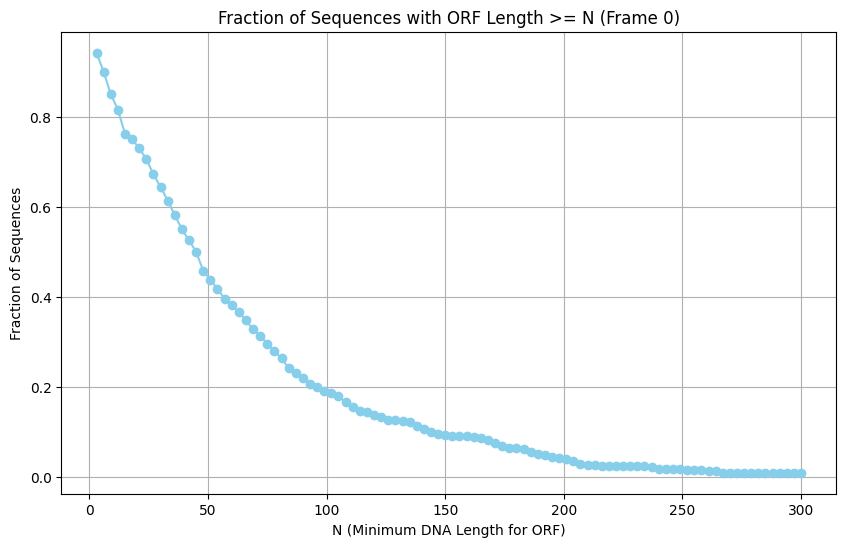

In [11]:
import matplotlib.pyplot as plt

# Extract keys (N values) and values (fractions) from the dictionary
N_values = list(fractions_dict.keys())
fractions = list(fractions_dict.values())

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(N_values, fractions, marker='o', linestyle='-', color='skyblue')

# Add labels and title
plt.xlabel('N (Minimum DNA Length for ORF)')
plt.ylabel('Fraction of Sequences')
plt.title('Fraction of Sequences with ORF Length >= N (Frame 0)')
plt.grid(True)

# Show the plot
plt.show()

## A poor man's ORF finder
We will simply translate a given input DNA sequence in all six frames and count the longest stretch of amino acid sequences with or without a start codon.

First, let's use a real DNA sequence encoding some protein coding gene. The record is [here](https://ncbi.nlm.nih.gov/nuccore/J01749.1). We are using the 1-1300 bp of it.

In [12]:
# Define the real DNA sequence from the FASTA record
input_dna = "TTCTCATGTTTGACAGCTTATCATCGATAAGCTTTAATGCGGTAGTTTATCACAGTTAAATTGCTAACGCAGTCAGGCACCGTGTATGAAATCTAACAATGCGCTCATCGTCATCCTCGGCACCGTCACCCTGGATGCTGTAGGCATAGGCTTGGTTATGCCGGTACTGCCGGGCCTCTTGCGGGATATCGTCCATTCCGACAGCATCGCCAGTCACTATGGCGTGCTGCTAGCGCTATATGCGTTGATGCAATTTCTATGCGCACCCGTTCTCGGAGCACTGTCCGACCGCTTTGGCCGCCGCCCAGTCCTGCTCGCTTCGCTACTTGGAGCCACTATCGACTACGCGATCATGGCGACCACACCCGTCCTGTGGATCCTCTACGCCGGACGCATCGTGGCCGGCATCACCGGCGCCACAGGTGCGGTTGCTGGCGCCTATATCGCCGACATCACCGATGGGGAAGATCGGGCTCGCCACTTCGGGCTCATGAGCGCTTGTTTCGGCGTGGGTATGGTGGCAGGCCCCGTGGCCGGGGGACTGTTGGGCGCCATCTCCTTGCATGCACCATTCCTTGCGGCGGCGGTGCTCAACGGCCTCAACCTACTACTGGGCTGCTTCCTAATGCAGGAGTCGCATAAGGGAGAGCGTCGACCGATGCCCTTGAGAGCCTTCAACCCAGTCAGCTCCTTCCGGTGGGCGCGGGGCATGACTATCGTCGCCGCACTTATGACTGTCTTCTTTATCATGCAACTCGTAGGACAGGTGCCGGCAGCGCTCTGGGTCATTTTCGGCGAGGACCGCTTTCGCTGGAGCGCGACGATGATCGGCCTGTCGCTTGCGGTATTCGGAATCTTGCACGCCCTCGCTCAAGCCTTCGTCACTGGTCCCGCCACCAAACGTTTCGGCGAGAAGCAGGCCATTATCGCCGGCATGGCGGCCGACGCGCTGGGCTACGTCTTGCTGGCGTTCGCGACGCGAGACTGGATGGCCTTCCCCATTATGATTCTTCTCGCTTCCGGCGGCATCGGGATGCCCGCGTTGCAGGCATGCTGTCCAGGCAGGTAGATGACGACCATCAGGGACAGCTTCAAGGATCGCTCGCGGCTCTTACCAGCCTAACTTCGATCACTGGACCGCTGATCGTCACGGCGATTTATGCCGCCTCGGCGAGCACATGGAACGGGTTGGCATGGATTGTAGGCGCCGCCCTATACCTTGTCTGCCTCCCCGCGTTGCGTCGCGGTGCATGGAGCCGGGCCACCTCGACCTGAATGGAAGCCGGCGGCACCTCGCTA"

Now, we will generate 1000 randomized versions of the input DNA sequence, each by shuffling the letters.

In [13]:
def shuffle_dna_sequence(dna_sequence):
    # Convert the string to a list of characters to shuffle
    dna_list = list(dna_sequence)
    random.shuffle(dna_list)
    # Join the characters back into a string
    return ''.join(dna_list)

num_shuffles = 1000
shuffled_dna_sequences = []

for _ in range(num_shuffles):
    shuffled_dna_sequences.append(shuffle_dna_sequence(input_dna))

print(f"Generated {len(shuffled_dna_sequences)} randomly shuffled DNA sequences.")
# Print the first few shuffled sequences to verify
for i, s in enumerate(shuffled_dna_sequences[:5]):
    print(f"Shuffled String {i+1}: {s[:60]} ...")

Generated 1000 randomly shuffled DNA sequences.
Shuffled String 1: CGCTATATAATTCTCATGTAGTGCACGGCCATGTGGGGTACCGCCGCTGGGCAACCAAGC ...
Shuffled String 2: TAGCGCCCCATGGCCCGTTGCGCAGGTGCATGTGAAGACGTGGCCGCCGGTTCCTACGCG ...
Shuffled String 3: TAGAAATGCCCGTCTGCTGTCTGATGGCACCTCTGGTCAGCGCATCGGGCCACCTTATGA ...
Shuffled String 4: TCGCCCCGCCCCTCGCCCCTGTGCCAAAGACGGGGACTGCAGCTGATCTCTTATGTAGAT ...
Shuffled String 5: GGGCTCCGTTTGTTCCTACTTTGCGCGTATGTCTGCGGGGGGTAAGGTAAACTCCGGGTG ...


In [16]:
def reverse_complement(dna_sequence):
    complement_map = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    rev_seq_list = [complement_map[base] for base in reversed(dna_sequence)]
    return ''.join(rev_seq_list)

def find_longest_orf(dna_sequence, genetic_code):
    all_orfs_details = [] # Stores (orf_sequence, orf_length, start_pos, strand)

    # --- Search on Forward Strand (frames 0, 1, 2 for start codon) ---
    # We don't iterate frames here, but search for ATG and then translate frame 0 from there.
    L = len(dna_sequence)
    for i in range(L - 2):
        codon = dna_sequence[i : i + 3]
        if codon == 'ATG':
            translated_part = translate_dna(dna_sequence[i:], frame=0)
            if translated_part: # Ensure it's not empty (e.g., immediate stop codon)
                all_orfs_details.append({
                    'sequence': translated_part,
                    'length': len(translated_part),
                    'start_position': i,
                    'strand': '+'
                })

    # --- Search on Reverse Complement Strand ---
    rev_comp_dna = reverse_complement(dna_sequence)
    for i in range(len(rev_comp_dna) - 2):
        codon = rev_comp_dna[i : i + 3]
        if codon == 'ATG':
            translated_part = translate_dna(rev_comp_dna[i:], frame=0)
            if translated_part:
                # Calculate start position in the original DNA sequence (0-indexed)
                # The start of the ORF in reverse complement (index i)
                # corresponds to the end of the translated region in the original sequence.
                # The *start* of the corresponding region in the original sequence is:
                # L - (position of the last nucleotide of the ORF in RC + 1)
                # Or, L - (i + len(translated_part)*3)
                start_in_original_dna = L - (i + len(translated_part) * 3)
                all_orfs_details.append({
                    'sequence': translated_part,
                    'length': len(translated_part),
                    'start_position': start_in_original_dna,
                    'strand': '-'
                })

    if not all_orfs_details:
        return 0, [] # No ORFs found, return 0 length and empty list

    # Find the maximum ORF length
    max_orf_length = 0
    if all_orfs_details:
        max_orf_length = max(orf['length'] for orf in all_orfs_details)

    # Collect all ORFs that match the maximum length
    longest_orfs = [orf for orf in all_orfs_details if orf['length'] == max_orf_length]

    return max_orf_length, longest_orfs

# Apply to the real DNA sequence
real_dna_orf_length, real_dna_longest_orfs = find_longest_orf(input_dna, genetic_code)
print(f"Real DNA Sequence Longest ORF Length: {real_dna_orf_length}")
for orf_detail in real_dna_longest_orfs:
    print(f"  Sequence: {orf_detail['sequence'][:60]}... (Length: {orf_detail['length']}), Start: {orf_detail['start_position']}, Strand: {orf_detail['strand']}")

# Apply to the shuffled DNA sequences
shuffled_max_orf_lengths = []
shuffled_all_longest_orf_details = [] # Store details of all longest ORFs from all shuffled sequences

for i, dna_seq in enumerate(shuffled_dna_sequences):
    orf_length, longest_orfs_for_this_seq = find_longest_orf(dna_seq, genetic_code)
    shuffled_max_orf_lengths.append(orf_length) # Store just the longest length for the histogram
    shuffled_all_longest_orf_details.extend(longest_orfs_for_this_seq) # Store all longest ORFs for this sequence

print(f"\nProcessed {len(shuffled_dna_sequences)} shuffled DNA sequences.")
print(f"First 5 Shuffled DNA Longest ORF Lengths: {shuffled_max_orf_lengths[:5]}")

# Print details for an example of a longest ORF found among all shuffled sequences for verification
if shuffled_all_longest_orf_details:
    print("\nExample of a longest ORF from a shuffled sequence (first one encountered):")
    first_longest_shuffled_orf = shuffled_all_longest_orf_details[0]
    print(f"  Sequence: {first_longest_shuffled_orf['sequence'][:60]}... (Length: {first_longest_shuffled_orf['length']}), Start: {first_longest_shuffled_orf['start_position']}, Strand: {first_longest_shuffled_orf['strand']}")

Real DNA Sequence Longest ORF Length: 327
  Sequence: MKSNNALIVILGTVTLDAVGIGLVMPVLPGLLRDIVHSDSIASHYGVLLALYALMQFLCA... (Length: 327), Start: 85, Strand: +

Processed 1000 shuffled DNA sequences.
First 5 Shuffled DNA Longest ORF Lengths: [97, 105, 75, 147, 153]

Example of a longest ORF from a shuffled sequence (first one encountered):
  Sequence: MLSEVGTDSLRTPMRRSQPGDRVYCQPPPYGPRRVCGVLPARIVSNCRRGWGGCLIVTLD... (Length: 97), Start: 175, Strand: +


## Comparing ORF Lengths: Real vs. Shuffled Sequences

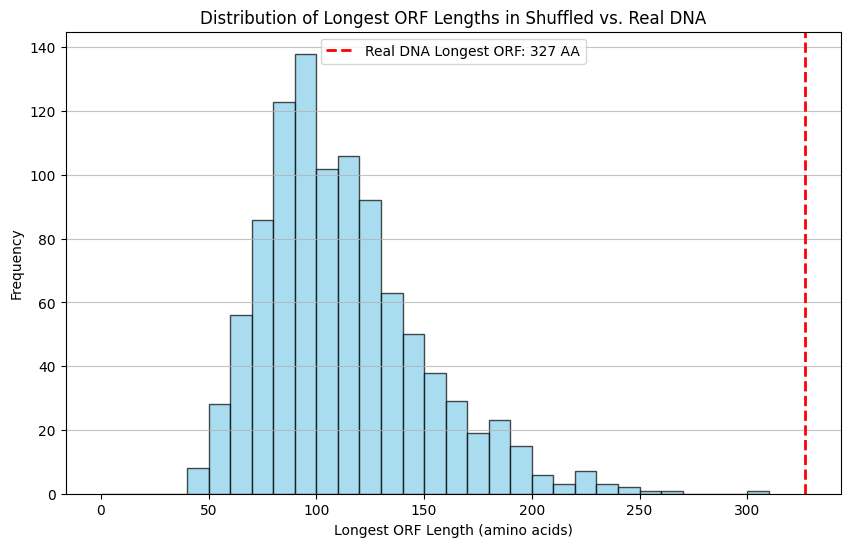

In [18]:
import numpy as np

# Plotting the histogram of shuffled ORF lengths
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_orf_lengths, bins=range(0, max(shuffled_max_orf_lengths) + 10, 10), color='skyblue', edgecolor='black', alpha=0.7)

# Mark the longest ORF of the real DNA sequence
plt.axvline(x=real_dna_orf_length, color='red', linestyle='--', linewidth=2, label=f'Real DNA Longest ORF: {real_dna_orf_length} AA')

# Add labels and title
plt.xlabel('Longest ORF Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Distribution of Longest ORF Lengths in Shuffled vs. Real DNA')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()